# Chapter 5, Example 2: Reparametrization, local beliefs, and belief-propagation consistency

A reparametrization preserves the complete probability distribution, not only its partition function. We use a binary three-variable chain with pair factors $f_{12}$ and $f_{23}$.

For positive functions $R_{A\to i}(x_i)$, define

$$
B_i(x_i)\propto\prod_{A\ni i}R_{A\to i}(x_i),
$$

and

$$
B_A(\boldsymbol{x}_A)\propto f_A(\boldsymbol{x}_A)
\prod_{i\in A}\prod_{C\ni i,\,C\neq A}R_{C\to i}(x_i).
$$

Then the exact joint distribution can be reconstructed as

$$
p(\boldsymbol{x})\propto
\frac{\prod_A B_A(\boldsymbol{x}_A)}{\prod_i B_i(x_i)^{q_i-1}}.
$$

In [1]:
from pathlib import Path
import math
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

CWD = Path.cwd()
if CWD.name == "ch05":
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks" / "ch05").exists():
    NOTEBOOK_DIR = CWD / "notebooks" / "ch05"
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 18,
})

NODE_COLOR = "#3f4c6b"
SECONDARY_NODE_COLOR = "#5b6784"
PINNED_NODE_COLOR = "#7b3f4c"


def save_figure(fig, stem):
    for suffix, kwargs in [("pdf", {}), ("png", {"dpi": 240})]:
        path = FIG_DIR / f"{stem}.{suffix}"
        fig.savefig(path, bbox_inches="tight", **kwargs)
        print(f"Saved: {path}")


def annotate_heatmap(ax, matrix, image, fmt=".2f"):
    norm = image.norm
    cmap = image.cmap
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            rgba = cmap(norm(matrix[i, j]))
            luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
            color = "black" if luminance > 0.58 else "white"
            ax.text(j, i, format(matrix[i, j], fmt), ha="center", va="center", color=color, fontsize=13)


## Original pairwise model

In [2]:
states = np.array([-1, 1])
J12, J23 = 0.82, -0.56
h1, h2, h3 = 0.18, -0.12, 0.26

f12 = np.exp(J12*np.outer(states, states) + 0.5*h1*states[:,None] + 0.5*h2*states[None,:])
f23 = np.exp(J23*np.outer(states, states) + 0.5*h2*states[:,None] + 0.5*h3*states[None,:])

configs = np.array(list(product(range(2), repeat=3)))
weights = np.array([f12[i,j]*f23[j,k] for i,j,k in configs])
p = weights/weights.sum()
print("Partition function:", weights.sum())
display(pd.DataFrame({"state": [tuple(states[c]) for c in configs], "probability": p}))

Partition function: 12.795485061694368


,state,probability
0,"(-1, -1, -1)",0.091713
1,"(-1, -1, 1)",0.364550
2,"(-1, 1, -1)",0.042891
3,"(-1, 1, 1)",0.018150
4,"(1, -1, -1)",0.021299
5,"(1, -1, 1)",0.084662
6,"(1, 1, -1)",0.264717
7,"(1, 1, 1)",0.112018


## An arbitrary positive reparametrization

The trial functions below are deliberately not selected by belief propagation. The reconstructed global distribution remains exact, but the local beliefs need not agree on their shared variables.

In [3]:
R = {
    ("12",1): np.array([0.72, 1.31]),
    ("12",2): np.array([1.18, 0.77]),
    ("23",2): np.array([0.83, 1.24]),
    ("23",3): np.array([1.29, 0.69]),
}

def normalize(a):
    return a/a.sum()

B1 = normalize(R[("12",1)])
B2 = normalize(R[("12",2)]*R[("23",2)])
B3 = normalize(R[("23",3)])
B12 = f12 * R[("23",2)][None,:]
B12 /= B12.sum()
B23 = f23 * R[("12",2)][:,None]
B23 /= B23.sum()

reconstructed_weight = np.array([B12[i,j]*B23[j,k]/B2[j] for i,j,k in configs])
reconstructed = reconstructed_weight/reconstructed_weight.sum()
print("Maximum global-distribution error:", np.max(np.abs(reconstructed-p)))
assert np.allclose(reconstructed, p)

residuals_arbitrary = {
    "B12 -> B1": np.max(np.abs(B12.sum(axis=1)-B1)),
    "B12 -> B2": np.max(np.abs(B12.sum(axis=0)-B2)),
    "B23 -> B2": np.max(np.abs(B23.sum(axis=1)-B2)),
    "B23 -> B3": np.max(np.abs(B23.sum(axis=0)-B3)),
}
display(pd.Series(residuals_arbitrary, name="inconsistency").to_frame())

Maximum global-distribution error: 5.551115123125783e-17


,inconsistency
B12 -> B1,0.054028
B12 -> B2,0.105713
B23 -> B2,0.157023
B23 -> B3,0.281641


## Belief propagation fixes the reparametrization freedom on a tree

On a tree, sum-product messages can be computed by a finite inward-outward pass. At the fixed point, the factor and variable beliefs are exactly marginally consistent and coincide with the true marginals.

In [4]:
# Factor-to-variable messages. Leaves send the all-one variable-to-factor message.
m12_to_1 = f12.sum(axis=1)
m12_to_2 = f12.sum(axis=0)
m23_to_2 = f23.sum(axis=1)
m23_to_3 = f23.sum(axis=0)

# Correct central messages account for the opposite factor.
m12_to_1 = f12 @ m23_to_2
m23_to_3 = f23.T @ m12_to_2

Rbp = {
    ("12",1): m12_to_1,
    ("12",2): m12_to_2,
    ("23",2): m23_to_2,
    ("23",3): m23_to_3,
}
B1_bp = normalize(Rbp[("12",1)])
B2_bp = normalize(Rbp[("12",2)]*Rbp[("23",2)])
B3_bp = normalize(Rbp[("23",3)])
B12_bp = f12 * Rbp[("23",2)][None,:]
B12_bp /= B12_bp.sum()
B23_bp = f23 * Rbp[("12",2)][:,None]
B23_bp /= B23_bp.sum()

residuals_bp = {
    "B12 -> B1": np.max(np.abs(B12_bp.sum(axis=1)-B1_bp)),
    "B12 -> B2": np.max(np.abs(B12_bp.sum(axis=0)-B2_bp)),
    "B23 -> B2": np.max(np.abs(B23_bp.sum(axis=1)-B2_bp)),
    "B23 -> B3": np.max(np.abs(B23_bp.sum(axis=0)-B3_bp)),
}
true_marginals = [np.array([p[configs[:,i]==v].sum() for v in range(2)]) for i in range(3)]
print("Maximum BP marginal error:", max(np.max(np.abs(b-t)) for b,t in zip([B1_bp,B2_bp,B3_bp],true_marginals)))
display(pd.Series(residuals_bp, name="inconsistency").to_frame())

Maximum BP marginal error: 5.551115123125783e-17


,inconsistency
B12 -> B1,5.551115e-17
B12 -> B2,5.551115e-17
B23 -> B2,5.551115e-17
B23 -> B3,5.551115e-17


## Figures

Saved: figs/ch05_02_distribution_invariance.pdf
Saved: figs/ch05_02_distribution_invariance.png


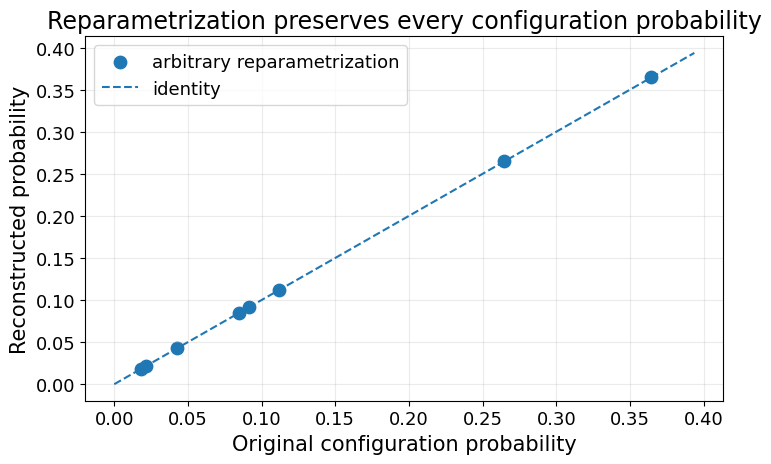

Saved: figs/ch05_02_belief_consistency.pdf
Saved: figs/ch05_02_belief_consistency.png


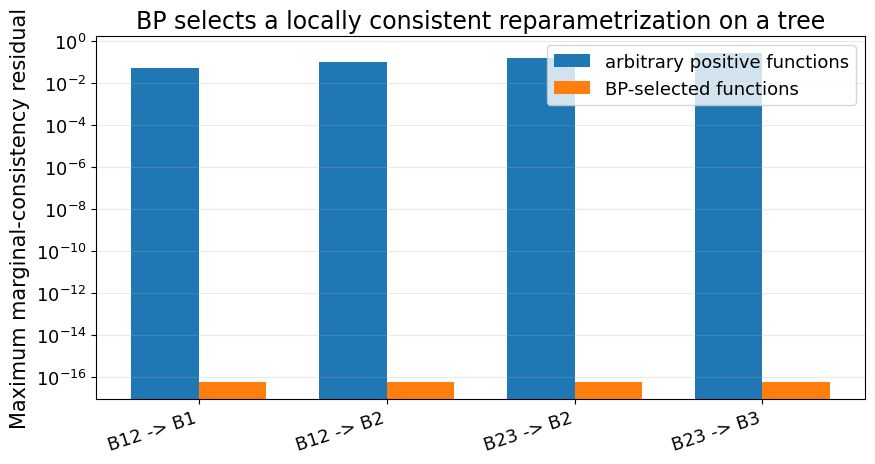

In [5]:
fig, ax = plt.subplots(figsize=(7.6, 4.9))
ax.scatter(p, reconstructed, s=80, label="arbitrary reparametrization")
upper = 1.08*max(p.max(), reconstructed.max())
ax.plot([0,upper],[0,upper], linestyle="--", linewidth=1.5, label="identity")
ax.set_xlabel("Original configuration probability")
ax.set_ylabel("Reconstructed probability")
ax.set_title("Reparametrization preserves every configuration probability")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
save_figure(fig, "ch05_02_distribution_invariance")
plt.show()

labels = list(residuals_arbitrary)
x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(9.0, 4.9))
width=0.36
ax.bar(x-width/2, [residuals_arbitrary[k] for k in labels], width, label="arbitrary positive functions")
ax.bar(x+width/2, [residuals_bp[k] for k in labels], width, label="BP-selected functions")
ax.set_xticks(x, labels, rotation=18, ha="right")
ax.set_yscale("log")
ax.set_ylabel("Maximum marginal-consistency residual")
ax.set_title("BP selects a locally consistent reparametrization on a tree")
ax.grid(axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
save_figure(fig, "ch05_02_belief_consistency")
plt.show()

## Exercises

1. Change the arbitrary $R$ functions by several orders of magnitude. Confirm that the global distribution remains unchanged while numerical conditioning deteriorates.
2. Repeat the BP construction on the four-spin chain from Chapter 2.
3. Add a third pair factor joining variables $1$ and $3$. Run loopy BP and compare local consistency, convergence, and exact marginals.
4. Derive the local normalization factor relating the original partition function to the reparametrized partition function.